In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

Setup Pytrends library and define the keyword

In [34]:
pytrends = TrendReq(hl='en-US', tz=360) # hl for host language, tz for timezone (360 for BD)
keyword = "Robotics" # Change this keyword to search for different things

Data Request

In [35]:
pytrends.build_payload([keyword] , cat=0, timeframe='today 12-m', geo='', gprop='')
#cat=0 ALL CATEGORY
#geo='' GLOBAL

A reusable function was created that allows flexible keyword-based trend analysis by changing only the keyword parameter.

Top 15 countries where the keyword is searched the most + visualization

In [36]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keyword, ascending = False).head(15)

C:\Users\Asus\AppData\Local\Temp\ipykernel_12520\3779917833.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




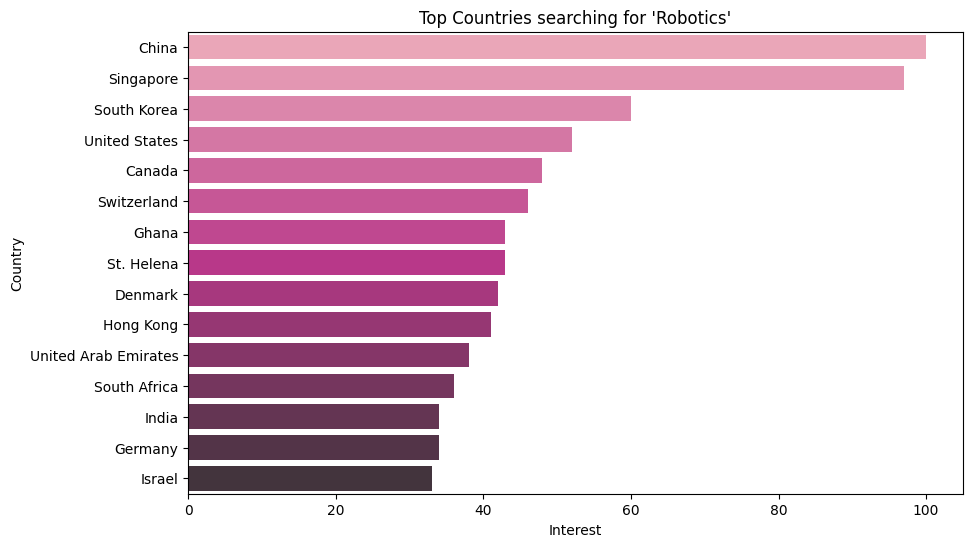

In [37]:
plt.figure(figsize = (10,6))
sns.barplot(x = region_data[keyword], y = region_data.index, palette = "RdPu_d")
plt.title(f"Top Countries searching for '{keyword}'")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

WORLD MAP

In [39]:
region_data = region_data.reset_index()

fig = px.choropleth(
    region_data,
    locations='geoName',
    locationmode='country names',
    color=keyword,
    title=f"Search Interest for '{keyword}' by Country",
    color_continuous_scale='RdPu'
)

fig.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_12520\72679537.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Extract time-wise interest of the keyword (trend over years)

In [40]:
time_df=pytrends.interest_over_time()

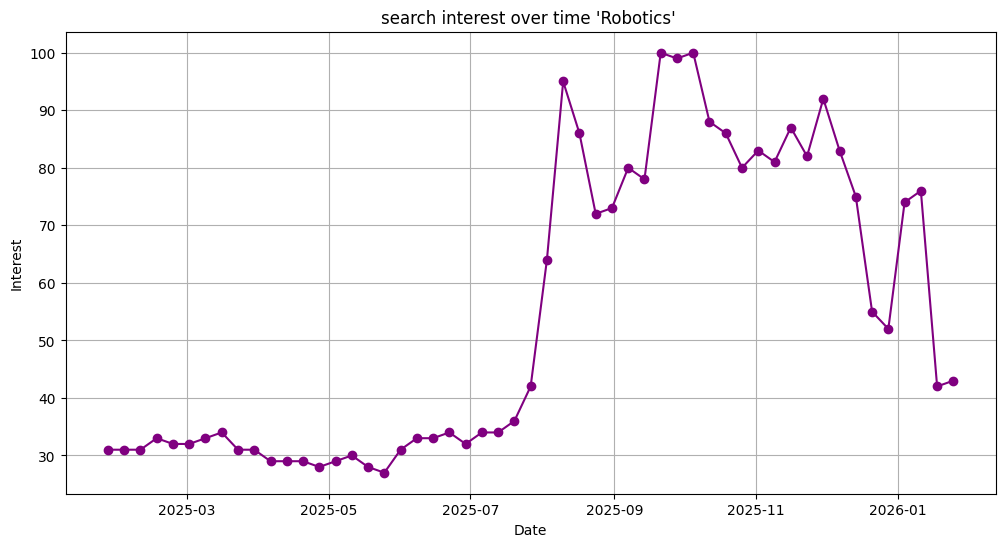

In [42]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker='o', color='purple')
plt.title(f"search interest over time '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

Compare related keywords and plot the graph

In [43]:
kw_list = ["artificial intelligence", "deep learning", "data analytics"]
pytrends.build_payload(kw_list, cat = 0, timeframe = 'today 12-m', geo = '', gprop = '')

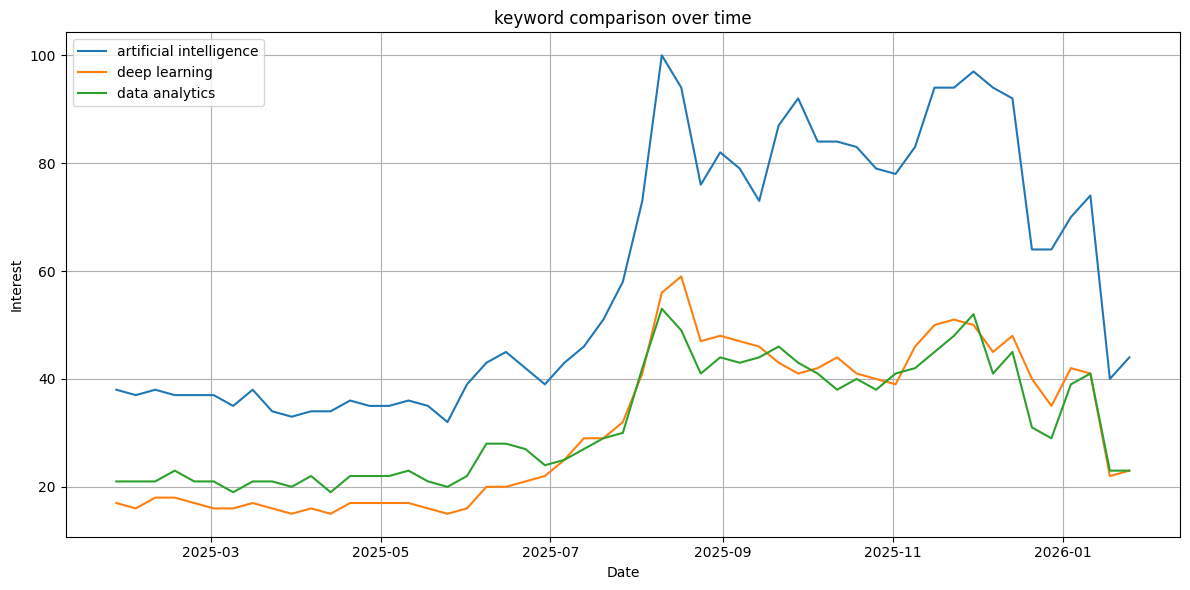

In [44]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label = kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This project analyzed Google search trends to understand keyword popularity over time and across countries using real-time data from the Google Trends API.